In [1]:
from IPython.display import display, Markdown
from solvers.background import solve_lane_emden
import matplotlib.pyplot as plt
import numpy as np
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
n = 1
#rho_c = 1
#P_c = 1

xi_surf, sol = solve_lane_emden(n)


xi_plot = np.linspace(1e-5, xi_surf, 500)


theta_plot = sol.sol(xi_plot)[0]


theta = np.maximum(theta_plot, 1e-2)
dtheta_dxi = sol.sol(xi_plot)[1]


rho = theta_plot**n
p = theta_plot**(n + 1.0)


In [3]:
from solvers.background import solve_lane_emden
from scipy.interpolate import interp1d
from scipy.optimize import brentq
from solvers.shooting import solve_system,get_eigenfrequency, get_eigenfunction,rayleigh_quotient

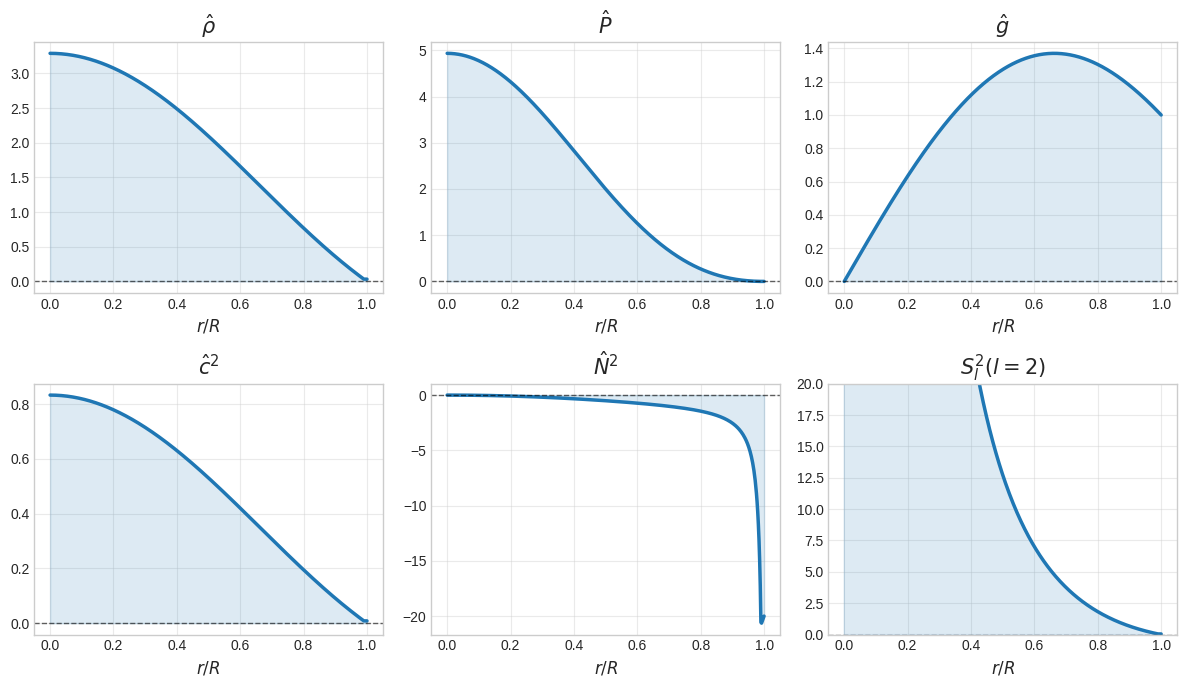

In [4]:
#Ορισμός των αδιάστατων μεταβλητών
gamma = 5/3
l=2
xi1 = sol.t_events[0][0] #Ακτίνα άστρου

th_prime_xi1 = sol.y_events[0][0][1] 

rho_hat = (-xi1 * theta**n)/(3*th_prime_xi1) #Αδιάστατη πυκνότητα
P_hat = theta**(n+1)/((n+1)*th_prime_xi1**2) #Αδιάστατη πίεση
g_hat = dtheta_dxi/th_prime_xi1 #Αδιάστατο g
c2_hat = -gamma*theta/(xi1*(n+1)*th_prime_xi1) #Αδιάστατη ταχύτητα του ήχου

N2_hat = ((n+1)/gamma - n) * (g_hat * dtheta_dxi *xi1)/(theta)

x = xi_plot/xi1
Sl_hat = (l*(l+1)*c2_hat)/x**2
bg_rho = interp1d(x, rho_hat, kind="cubic", fill_value=0.0, bounds_error=False)
bg_P = interp1d(x, P_hat, kind="cubic", fill_value=0.0, bounds_error=False)
bg_g   = interp1d(x, g_hat,   kind="cubic", fill_value=0.0, bounds_error=False)
bg_c2  = interp1d(x, c2_hat,  kind="cubic", fill_value=0.0, bounds_error=False)
bg_N2  = interp1d(x, N2_hat,  kind="cubic", fill_value=0.0, bounds_error=False)# 1. Καθολικές αισθητικές ρυθμίσεις γραμματοσειρών
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

quantities = {
    r'$\hat{\rho}$':  rho_hat,
    r'$\hat{P}$':     P_hat,
    r'$\hat{g}$':     g_hat,
    r'$\hat{c}^2$':   c2_hat,
    r'$\hat{N}^2$':   N2_hat,
    r'$S_l^2 (l=2)$': Sl_hat,
}

# 2. Επιλογή χρώματος για τις γραμμές και τη σκίαση
primary_color = '#1f77b4' 

for ax, (label, qty) in zip(axes.flatten(), quantities.items()):
    # 3. Πιο παχιά γραμμή
    ax.plot(x, qty, linewidth=2.5, color=primary_color)
    
    # 4. Ελαφριά ημιδιαφανής σκίαση (fill_between)
    ax.fill_between(x, qty, 0, color=primary_color, alpha=0.15)
    
    # Πιο διακριτική διακεκομμένη γραμμή στο 0
    ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)
    
    ax.set_xlabel(r'$r/R$')
    ax.set_title(label)
    
    # Διακριτικό πλέγμα
    ax.grid(True, alpha=0.4, linestyle='-')
    
    # 5. Στοχευμένο όριο y μόνο για το S_l^2 που απειρίζεται κοντά στο 0
    if label == r'$S_l^2 (l=2)$':
        ax.set_ylim(0, 20)

# Διόρθωση του τίτλου (έλειπε η παρένθεση) και προσθήκη του γ
# Το y=1.02 δίνει λίγο 'αέρα' ανάμεσα στον τίτλο και τα γραφήματα
#plt.suptitle(rf'Background πολυτροπικού αστέρα ($n={n}$, $\gamma=5/3$)', fontsize=16, y=1.02)

plt.tight_layout()
plt.savefig('background.png', bbox_inches='tight')
plt.show()

np.savez("newtonian.npz",x=x,rho_hat=rho_hat,P_hat=P_hat)


<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_52304/2398255285.py:21: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("Δοκιμαστική Συχνότητα $\hat{\omega}^2$", fontsize=12)


Σαρώνω τον χώρο των συχνοτήτων. Υπομονή...


/tmp/ipykernel_52304/2398255285.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


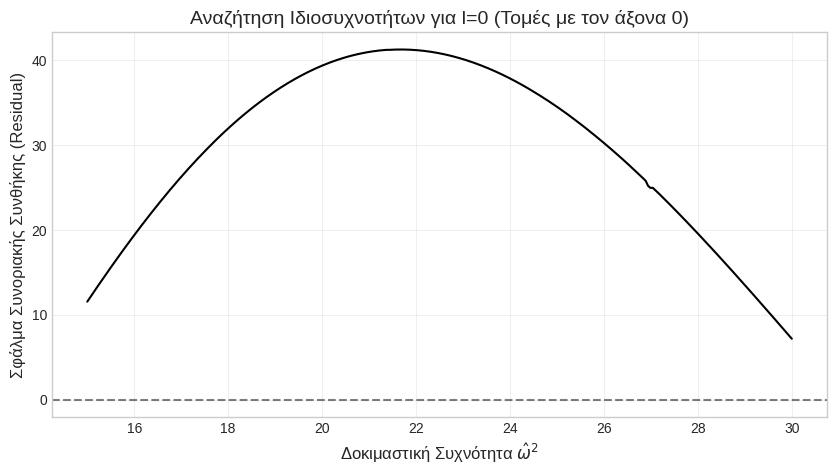

In [6]:
# --- Scan για τις ρίζες ---
l = 0
omega2_scan = np.linspace(15,30, 300)
residuals = []

print("Σαρώνω τον χώρο των συχνοτήτων. Υπομονή...")

for w2 in omega2_scan:
    try:
        res = solve_system(w2, l, bg_rho=bg_rho, bg_g=bg_g, bg_c2=bg_c2, bg_N2=bg_N2)
        residuals.append(res)
    except:
        residuals.append(np.nan)

residuals = np.array(residuals)

# --- Γράφημα του Scan ---
plt.figure(figsize=(10, 5))
plt.plot(omega2_scan, residuals, color='black', lw=1.5)
plt.axhline(y=0,color="black",alpha=0.5, linestyle='--')
plt.xlabel("Δοκιμαστική Συχνότητα $\hat{\omega}^2$", fontsize=12)
plt.ylabel("Σφάλμα Συνοριακής Συνθήκης (Residual)", fontsize=12)
plt.title(f"Αναζήτηση Ιδιοσυχνοτήτων για l={l} (Τομές με τον άξονα 0)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("scan.png")
plt.show()

Αποτυχία εύρεσης ρίζας στο διάστημα [5.0, 6.0].
Σφάλμα: f(a) and f(b) must have different signs
Αποτυχία εύρεσης ρίζας στο διάστημα [9, 10].
Σφάλμα: f(a) and f(b) must have different signs
Αποτυχία εύρεσης ρίζας στο διάστημα [17, 18.0].
Σφάλμα: f(a) and f(b) must have different signs
Αποτυχία εύρεσης ρίζας στο διάστημα [30.0, 32.0].
Σφάλμα: f(a) and f(b) must have different signs


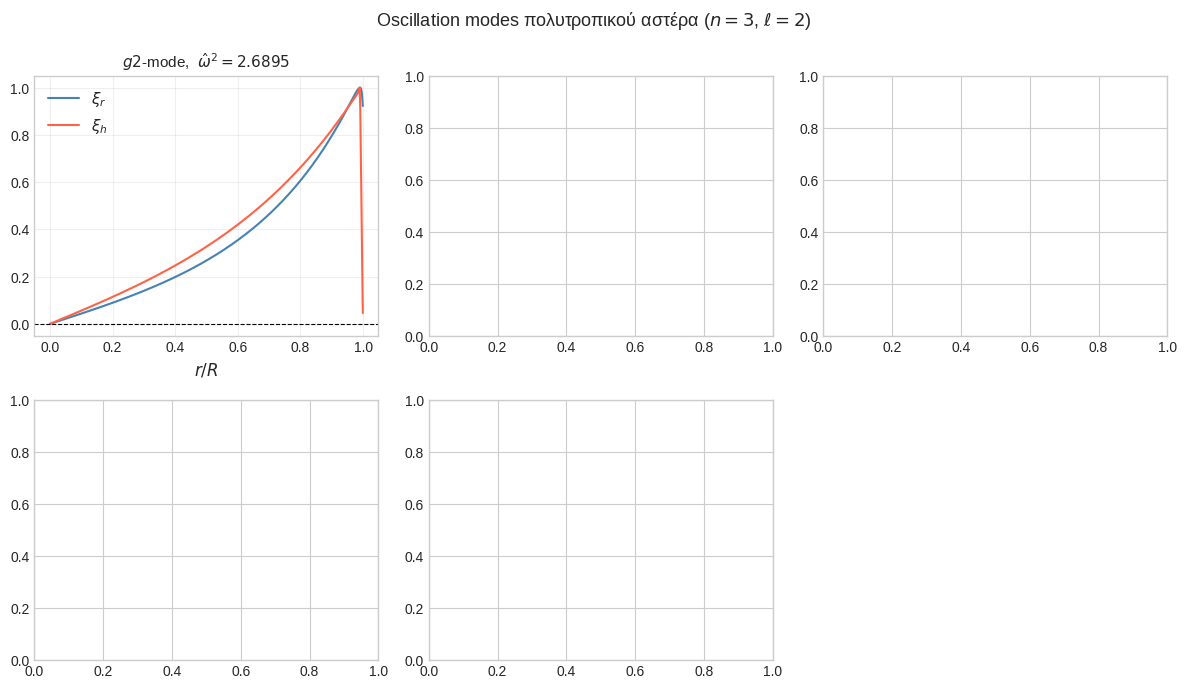

In [7]:
l = 2

modes= {
    "g2": (2.5, 3),
    "g1": (5.0,6.0), 
    "f": (9,10),
    "p1": (17,18.0),
    "p2": (30.0,32.0)
}
 
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, (mode, (w_min, w_max)) in enumerate(modes.items()):
    eigen_freq = get_eigenfrequency(l, w_min, w_max, bg_rho, bg_g, bg_c2, bg_N2)
    if eigen_freq is None:
        continue
    
    solution = get_eigenfunction(eigen_freq, l, bg_rho, bg_g, bg_c2, bg_N2)
    x = np.linspace(1e-4, 0.999, 500)
    y1 = solution.sol(x)[0]
    y1_norm = y1 / np.max(np.abs(y1))
    y2 = solution.sol(x)[1]

    xi_h = y2/(x*eigen_freq**2 * bg_rho(x))
    xi_h_norm = xi_h/ np.max(np.abs(xi_h))
    ax = axes[i]
    ax.plot(x, y1_norm, color='steelblue', linewidth=1.5, label=r'$\xi_r$')
    ax.plot(x, xi_h_norm, color='tomato', linewidth=1.5,label=r'$\xi_h$')
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_title(rf'${mode}$-mode,  $\hat{{\omega}}^2 = {eigen_freq:.4f}$', fontsize=11)
    ax.set_xlabel(r'$r/R$')
    #ax.set_ylabel(r'$\xi_r$ (κανονικοποιημένο)')
    ax.grid(True, alpha=0.3)
    ax.legend()
# Κρύψε το 6ο subplot αν έχεις 5 modes
axes[-1].set_visible(False)

plt.suptitle(rf'Oscillation modes πολυτροπικού αστέρα ($n=3$, $\ell={l}$)', fontsize=13)
plt.tight_layout()
plt.savefig('eigenfunctions.png', bbox_inches='tight')
plt.show()

In [8]:
def P_newt(x):
    return gamma*bg_P(x)/x**2
def Q_newt(x):
    return -4 *(bg_rho(x)*bg_g(x))/(x**3)
def W_newt(x):
    return bg_rho(x)/x**2

Αποτυχία εύρεσης ρίζας στο διάστημα [9, 10].
Σφάλμα: f(a) and f(b) must have different signs


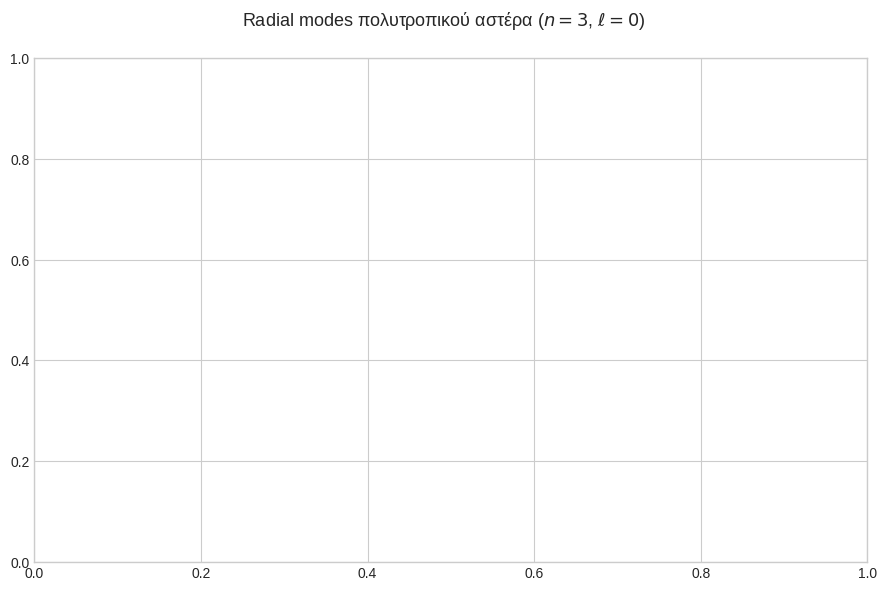

In [9]:
l = 0

modes= {
    "f": (9, 10)
}
 
fig, ax = plt.subplots(figsize=(9,6))

for i, (mode, (w_min, w_max)) in enumerate(modes.items()):
    eigen_freq = get_eigenfrequency(l, w_min, w_max, bg_rho, bg_g, bg_c2, bg_N2)
    if eigen_freq is None:
        continue
    
    solution = get_eigenfunction(eigen_freq, l, bg_rho, bg_g, bg_c2, bg_N2)
    x = np.linspace(1e-4, 0.99, 500)
    y1 = solution.sol(x)[0]/(x**2)
    y1_norm = y1 / np.max(np.abs(y1))
    
    ax.plot(x[:-7], y1_norm[:-7], color='steelblue', linewidth=1.5, label=r'$\xi_r$')
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_title(rf'${mode}$-mode,  $\hat{{\omega}}^2 = {eigen_freq:.4f}$', fontsize=11)
    ax.set_xlabel(r'$r/R$')
    #ax.set_ylabel(r'$\xi_r$ (κανονικοποιημένο)')
    ax.grid(True, alpha=0.3)
    ax.legend()

    #Εκτίμηση με πηλίκο Rayleigh της εκάστοτε συχνότητας: 
    zeta = solution.sol(x)[0]
    zetap = solution.sol(x)[1]
    omega2 = rayleigh_quotient(x,zeta,zetap,P_newt,Q_newt,W_newt)
    error = (omega2-eigen_freq)/eigen_freq
    output_text = rf"Εκτίμηση της συχνότητας της **{mode}**-mode μέσω του πηλίκου Rayleigh: $\omega^2 = {omega2:.4f}$, Σφάλμα: {error:.3f} \%"
    display(Markdown(output_text))
plt.suptitle(rf'Radial modes πολυτροπικού αστέρα ($n=3$, $\ell={l}$)', fontsize=13)
plt.tight_layout()
plt.savefig('radial.png', bbox_inches='tight')
plt.show()